# Benchmarking structured slots vs. mental bootstrapping

**Paper 1** — Whittington, Dorrell, Behrens, Ganguli, Barry (2025).
*A tale of two algorithms: structured slots explain prefrontal sequence memory
and are unified with hippocampal cognitive maps.* **Neuron** 113:321–333.
`10.1016/j.neuron.2024.10.017`

**Paper 2** — Yang, Lyu, Wang, Xie, Zhen, Lai, Zhang (2026).
*Mental bootstrapping enables human-level concept learning in self-supervised
deep models.* **Sci. Adv.** 12:eaea7202. `10.1126/sciadv.aea7202`

---

## Headline result from the run in this notebook

Block A complete (9 of 19 cells), T4, 2,000 problems, 10 epochs, 64×64,
1 seed, relational depth matched at `stages=3`. Chance = 12.5%.

| substrate | MB | NCD | PRD |
|---|---|---|---|
| CIM (Yang et al.) | **82.6** | 74.4 | 68.2 |
| WM slots (Whittington et al.) | **39.4** | 31.2 | 30.6 |
| EM memory (Whittington et al.) | **23.4** | 17.4 | 21.8 |

Two things follow, and one important thing does not. **MB wins in every
substrate**, so Yang et al.'s paradigm claim survives substitution of the
architecture — the strongest form of their argument. But **the effect is far
smaller than their table S4**, where NCD collapsed to 22.5%; here it reaches
74.4%. And the **paper-1 prediction is still untested**, because the
memory-load sweep (Tables 2–3) has not been run. Full reading in §9.

---

## Read this before running anything

**The two papers are not competing theories of the same thing,** so "run both
on the same tasks and see which wins" is not a well-posed experiment as stated.

| | Whittington et al. | Yang et al. |
|---|---|---|
| What it is | a theory of **sequence memory** | a **training paradigm** + architecture |
| Core claim | memories in weights (EM) and in activation slots (WM) are duals, and trade off with task size | training on *reduced* problems and testing on *full* ones yields abstract concepts without labels |
| Computation | **recall** — reproduce the item stored at a queried position | **relational induction** — infer a rule and apply it |
| Tasks | serial recall, delayed recall, n-back, cued recall | RAVEN / I-RAVEN / RAVEN-FAIR / PGM / Bongard-LOGO |

In an RPM the answer **is not stored anywhere**. It has to be inferred from
relations across the context. EM and WM as published solve recall. Dropping
them onto RAVEN would measure only that they were not built for it — a
guaranteed, uninformative loss.

## The comparison that *is* well posed

Yang et al. separate the two factors themselves. Their **table S4** holds the
architecture fixed (VPM + CIM) and swaps MB training for NCD/PRD training;
performance collapses. So *training objective* and *context substrate* are
independent axes, and we can cross them:

```
        context substrate   ×   training objective
        {CIM, WM, EM}           {MB, NCD, PRD}
```

Everything else — encoder, pseudo-sample construction, classifier, loss, test
protocol — is held identical, taken from the authors' released code. Only the
**Concept Induction Module is swapped**. Each paper's claim then becomes a
main effect on this grid:

* **Yang et al. predict** MB > NCD, PRD — and if the claim is about the
  *paradigm* rather than the architecture, that ordering should survive when
  CIM is replaced by a WM or EM substrate. **This held: see §9.**
* **Whittington et al. predict** a substrate × memory-load interaction. WM
  superposes items in a fixed-width activation vector, so interference must
  grow with item count. EM writes separate entries to a store that grows with
  item count, so it should degrade more gracefully. **Not yet tested — Tables
  2–3 are unrun.**

**This is an extension of both theories, not a reproduction of either.**
See §9.

## 0. Setup

Runs on a free Colab T4. CPU works but is roughly 20× slower.

In [1]:
import os, json, glob, math, time, itertools
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0))
os.makedirs("results", exist_ok=True)

torch 2.11.0+cu128 | device: cuda
Tesla T4


## 1. Testbed: a procedural RPM generator

RAVEN, PGM and Bongard-LOGO are multi-GB downloads. This notebook generates
problems procedurally instead, which has one decisive advantage for our
question: **matrix side length is a free parameter.** RAVEN is 3×3 only, and
the memory-load sweep is the whole point of the paper-1 arm.

* one object per cell (RAVEN's "Center" configuration)
* attributes `type` (polygon sides 3–8), `size`, `color`; 6 levels each
* row-wise rules per attribute: Constant, Progression, Arithmetic,
  DistributeThree
* 8 answer candidates
* OOD split holds out attribute×rule pairings at training time, mirroring the
  intent of PGM's held-out subdatasets

### The choice-set bias trap

My first generator built distractors as perturbations of the correct answer.
That places the answer at the **centroid** of the candidate set in attribute
space, so it can be recovered *without ever looking at the context* — exactly
the artifact that motivated I-RAVEN and RAVEN-FAIR. A context-free centroid cue
scored **29%** against 12.5% chance.

The fix: sample a cloud of distinct offset tuples, then translate the cloud so
the answer lands on a **uniformly random slot**. The cue drops to ~9%, i.e.
chance. `audit_choice_bias` below re-runs the check — **always run it** after
touching the generator.

In [2]:
N_LEVELS = 6
ATTRS = ("type", "size", "color")
RULES = ("Constant", "Progression", "Arithmetic", "DistributeThree")


def _apply_rule(rule, rng, width):
    if rule == "Constant":
        return [int(rng.integers(N_LEVELS))] * width
    if rule == "Progression":
        step = int(rng.choice([-2, -1, 1, 2])); span = step * (width - 1)
        lo, hi = max(0, -span), min(N_LEVELS - 1, N_LEVELS - 1 - span)
        if lo > hi:
            return _apply_rule("Constant", rng, width)
        s = int(rng.integers(lo, hi + 1))
        return [s + step * i for i in range(width)]
    if rule == "Arithmetic":
        head = [int(rng.integers(N_LEVELS)) for _ in range(width - 1)]
        return head + [int(sum(head) % N_LEVELS)]
    if rule == "DistributeThree":
        vals = rng.choice(N_LEVELS, size=width, replace=False)
        return [int(v) for v in rng.permutation(vals)]
    raise ValueError(rule)


def all_pairs():
    return {(a, r) for a in ATTRS for r in RULES}


def _sample_matrix(rng, width, allowed):
    rules, cells = {}, {}
    for attr in ATTRS:
        opts = [r for r in RULES if (attr, r) in allowed]
        rule = str(rng.choice(opts)); rules[attr] = rule
        if rule == "DistributeThree":
            base = rng.choice(N_LEVELS, size=width, replace=False)
            cells[attr] = [[int(v) for v in np.roll(base, -i)] for i in range(width)]
        else:
            cells[attr] = [_apply_rule(rule, rng, width) for _ in range(width)]
    return rules, cells


def _majority_leaks(answer, cands):
    for a in ATTRS:
        counts = np.bincount([c[a] for c in cands], minlength=N_LEVELS)
        if counts[answer[a]] == counts.max() and (counts == counts.max()).sum() == 1:
            return True
    return False


def _make_candidates(answer, rng, n_choices=8, tries=60):
    """Answer sits at a RANDOM slot in the perturbation cloud, not its centre."""
    na = len(ATTRS)
    cands = []
    for _ in range(tries):
        offsets, seen, guard = [], set(), 0
        while len(offsets) < n_choices and guard < 500:
            guard += 1
            off = [0] * na
            for i in rng.choice(na, size=int(rng.integers(1, na + 1)), replace=False):
                off[i] = int(rng.choice([-2, -1, 1, 2]))
            if tuple(off) not in seen:
                seen.add(tuple(off)); offsets.append(off)
        if len(offsets) < n_choices:
            continue
        base = offsets[int(rng.integers(n_choices))]   # slot carrying the answer
        cands, keys = [], set()
        for off in offsets:
            c = {a: int((answer[a] + off[i] - base[i]) % N_LEVELS)
                 for i, a in enumerate(ATTRS)}
            k = tuple(c[a] for a in ATTRS)
            if k in keys:
                break
            keys.add(k); cands.append(c)
        if len(cands) == n_choices and not _majority_leaks(answer, cands):
            return cands
    return cands


def render(cell, img_size=64):
    im = Image.new("L", (img_size, img_size), 255)
    d = ImageDraw.Draw(im)
    n = 3 + cell["type"]
    r = (0.22 + 0.055 * cell["size"]) * img_size
    grey = int(200 - 30 * cell["color"]); c = img_size / 2
    d.polygon([(c + r * np.cos(2 * np.pi * k / n - np.pi / 2),
                c + r * np.sin(2 * np.pi * k / n - np.pi / 2)) for k in range(n)],
              fill=grey, outline=0)
    return np.asarray(im, dtype=np.float32) / 255.0


def make_rpm_set(n, width=3, img_size=64, seed=0, allowed_pairs=None, n_choices=8):
    rng = np.random.default_rng(seed)
    allowed = allowed_pairs or all_pairs()
    n_ctx = width * width - 1
    ctx = np.zeros((n, n_ctx, img_size, img_size), np.float32)
    cho = np.zeros((n, n_choices, img_size, img_size), np.float32)
    tgt = np.zeros(n, np.int64)
    cache = {}

    def R(cell):
        k = (cell["type"], cell["size"], cell["color"])
        if k not in cache:
            cache[k] = render(cell, img_size)
        return cache[k]

    for i in range(n):
        _, cells = _sample_matrix(rng, width, allowed)
        grid = [{a: cells[a][r][c] for a in ATTRS}
                for r in range(width) for c in range(width)]
        answer = grid[-1]
        cands = _make_candidates(answer, rng, n_choices)
        cands = [cands[j] for j in rng.permutation(n_choices)]
        tgt[i] = int(np.argmax([all(c[a] == answer[a] for a in ATTRS) for c in cands]))
        for j, cell in enumerate(grid[:-1]):
            ctx[i, j] = R(cell)
        for j, cell in enumerate(cands):
            cho[i, j] = R(cell)
    return ctx, cho, tgt


def audit_choice_bias(choices, target, n=2000, seed=0):
    """Context-free centroid cue. Should sit at chance (1/n_choices)."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(target), size=min(n, len(target)), replace=False)
    hits = 0
    for i in idx:
        flat = choices[i].reshape(choices.shape[1], -1)
        hits += int(np.argmin(((flat - flat.mean(0, keepdims=True)) ** 2).sum(1)) == target[i])
    return hits / len(idx)

context (1500, 8, 64, 64) choices (1500, 8, 64, 64)
centroid-cue accuracy 0.092  (chance 0.125)


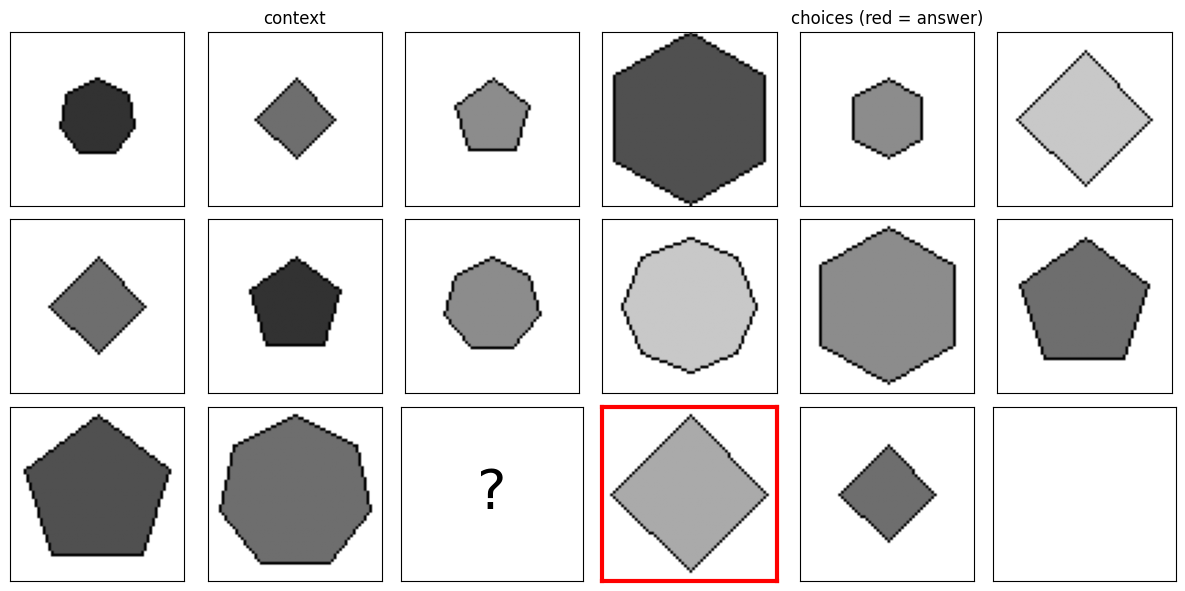

In [3]:
ctx, cho, tgt = make_rpm_set(1500, width=3, img_size=64, seed=0)
print("context", ctx.shape, "choices", cho.shape)
print(f"centroid-cue accuracy {audit_choice_bias(cho, tgt):.3f}  (chance 0.125)")
assert audit_choice_bias(cho, tgt) < 0.18, "choice set is biased -- fix before proceeding"

fig, ax = plt.subplots(3, 6, figsize=(12, 6))
for j in range(8):
    ax[j // 3, j % 3].imshow(ctx[0, j], cmap="gray", vmin=0, vmax=1)
ax[2, 2].text(.5, .5, "?", fontsize=40, ha="center", va="center"); ax[2, 2].set_xlim(0, 1)
for j in range(8):
    a = ax[j // 3, 3 + j % 3]
    a.imshow(cho[0, j], cmap="gray", vmin=0, vmax=1)
    if j == tgt[0]:
        for s in a.spines.values():
            s.set_color("red"); s.set_linewidth(3)
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([])
ax[0, 1].set_title("context", color="k"); ax[0, 4].set_title("choices (red = answer)")
plt.tight_layout(); plt.show()

## 2. The authors' SSLvMB, vendored

This section is derived from the released code (`SSLvMBcode/RPMcode/`), not
from my reading of the paper. Three things the released code makes clear that
the text alone does not:

1. **Rows *and* columns.** Every sample is `cat(row_order, col_order)`, so the
   Concept Induction Module sees **N=16** frames, not 8
   (`row2col = [0,3,6,1,4,7,2,5,8]`).
2. **The pseudo-positive is the intact context.** `_replace_choices` builds 10
   variants: index 0 is the untouched context, indices 1–8 replace one random
   position with each candidate, index 9 is a permuted context. Equivalent to
   the paper's "mask position *k* and put it back", but simpler to implement.
3. **Loss is BCE over the 10-vector with a one-hot target**, positive at index
   0 — not a per-sample independent BCE.

> ### ⚠️ Bug in the released code
> `networks/sslvmb.py` initialises `self.concept_inductor = []` and then calls
> `self.concept_extractor.append(...)`. `concept_extractor` is never created, so
> the constructor raises `AttributeError` as shipped. It is a one-character
> typo (`inductor` → `extractor`) and is fixed below. Worth reporting upstream.

In [4]:
class ConvBNAct(nn.Module):
    def __init__(self, cin, cout, use_act=True, conv_dim=2, **kw):
        super().__init__()
        L = [getattr(nn, f"Conv{conv_dim}d")(cin, cout, **kw),
             getattr(nn, f"BatchNorm{conv_dim}d")(cout)]
        if use_act:
            L.append(nn.ReLU())
        self.layer = nn.Sequential(*L)

    def forward(self, x):
        return self.layer(x)


class ResBlock(nn.Module):
    def __init__(self, cin, cout, downsample, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = ConvBNAct(cin, cout, kernel_size=3, stride=stride, padding=1, bias=False)
        self.conv2 = ConvBNAct(cout, cout, kernel_size=3, stride=1, padding=1, bias=False)
        self.conv3 = ConvBNAct(cout, cout, kernel_size=3, stride=1, padding=1, bias=False)
        self.downsample = downsample
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return self.drop(self.conv3(self.conv2(self.conv1(x)))) + self.downsample(x)


class CConvBlock(nn.Module):
    """Concept Convolution: convolves across the image axis N and spatial axis L."""

    def __init__(self, cin, cout, md=None, downsample=None, stride=1,
                 dropout=0.0, permute=False):
        super().__init__()
        self.permute = permute
        md = md or cout
        self.conv1 = ConvBNAct(cin, md, kernel_size=3, stride=stride, padding=1, bias=False)
        self.conv2 = ConvBNAct(md, cout, kernel_size=3, stride=1, padding=1, bias=False)
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.downsample = downsample

    def forward(self, x):
        if self.permute:                       # (B,N,C,L) -> (B,C,N,L)
            x = x.permute(0, 2, 1, 3)
        return self.drop(self.conv2(self.conv1(x))) + self.downsample(x)


class Classifier(nn.Module):
    def __init__(self, cin, cout, dropout=0.0, hidreduce=4):
        super().__init__()
        md = int(cin // hidreduce)
        self.fc1 = nn.Linear(cin, md, bias=False)
        self.bn1 = nn.BatchNorm1d(md)
        self.fc2 = nn.Linear(md, cout)
        self.relu, self.drop = nn.ReLU(), nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return self.fc2(self.drop(self.relu(self.bn1(self.fc1(x)))))


class ResNet4b(nn.Module):
    """VPM. Yang et al. eqs 1-3: four residual blocks, strides 2,2,2,1."""

    def __init__(self, in_channels=1, block_drop=0.0):
        super().__init__()
        chans, strides = [32, 64, 96, 128], [2, 2, 2, 1]
        self.in_channels, self.ou_channels = in_channels, chans[-1]
        self.num_stages = len(strides)
        for l, (c, s) in enumerate(zip(chans, strides)):
            setattr(self, f"res{l}", self._make(c, s, block_drop))
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")

    def _make(self, c, stride, drop):
        ds = nn.Sequential(
            nn.AvgPool2d(2, 2) if stride == 2 else nn.Identity(),
            ConvBNAct(self.in_channels, c, use_act=False, kernel_size=1, bias=False))
        blk = ResBlock(self.in_channels, c, ds, stride=stride, dropout=drop)
        self.in_channels = c
        return blk

    def forward(self, x):
        for l in range(self.num_stages):
            x = getattr(self, f"res{l}")(x)
        return x

## 3. The three context substrates

All three take `(B, N, C, L)` and return `(B, C', N, L)`, so they are drop-in
replacements inside the identical SSLvMB scaffolding. **The substrate is the
only thing that varies.**

### The relational-depth confound, and evidence it is now controlled

An earlier pilot compared raw accuracy across substrates and found
CIM ≫ WM ≫ EM. That comparison was **invalid**: CIM applies *three* nonlinear
mixing passes across the position axis, while the WM and EM heads applied only
*one* (their memory read). The gap conflated the memory mechanism with
relational depth.

`mix_stages` equalises it, and the run in this notebook used `stages=3`
throughout. **The ordering survived the fix**: CIM 82.6 / WM 39.4 / EM 23.4
with depth matched.

Two further checks make the ordering hard to explain away:

* **Parameter counts run against the winner** — CIM 1.27 M < WM 1.63 M <
  EM 2.29 M. The best substrate is the smallest, so this is not a capacity
  story.
* **EM is above chance** (23.4 vs 12.5), so the substrate is learning
  something; it is simply much worse at relational induction than convolution
  across the image axis.

That is the expected direction, and worth stating plainly: both memory
substrates were designed for *recall*, and this task is *induction*. The
result says convolution is a better inductive bias for rule induction — it
does **not** say anything yet about the EM/WM duality, which is a claim about
memory load. That needs Tables 2–3.

**Always match `mix_stages` to `num_extra_stages` when comparing substrates.**

In [5]:
class CIMHead(nn.Module):
    """Yang et al. Concept Induction Module (their released implementation)."""

    def __init__(self, c=64, stages=3, dropout=0.0):
        super().__init__()
        blocks = []
        for i in range(stages):
            ds = ConvBNAct(c, c, use_act=False, kernel_size=1, bias=False)
            blocks.append(CConvBlock(c, c, md=64, downsample=ds,
                                     dropout=dropout, permute=(i == 0)))
        self.blocks = nn.Sequential(*blocks)

    def forward(self, x):                       # (B,N,C,L)
        return self.blocks(x)                   # (B,C,N,L)


class MixStages(nn.Module):
    """Shared relational depth, so WM/EM match CIM's number of mixing passes."""

    def __init__(self, c, stages):
        super().__init__()
        self.blocks = nn.ModuleList([
            nn.Sequential(nn.Conv2d(c, c, 3, padding=1), nn.BatchNorm2d(c), nn.ReLU())
            for _ in range(max(0, stages - 1))])

    def forward(self, x):                       # (B,C,N,L)
        for b in self.blocks:
            x = b(x) + x
        return x


class WMSlotHead(nn.Module):
    """Whittington et al. WM: memories in ACTIVATIONS, under a fixed budget.

        h <- G h + W_in x_i        (one path-integration step per item)

    G is a fixed random rotation. Every item superposes into the same
    d_h-dimensional vector, so reading item p back (by un-rotating) carries
    crosstalk from every other item. Capacity is set by d_h and does NOT grow
    with N -- the property that generates the predicted scaling cost.
    """

    def __init__(self, c=64, L=64, d_h=512, stages=3, seed=0):
        super().__init__()
        self.c, self.L, self.d_h = c, L, d_h
        d_item = c * L
        self.w_in = nn.Linear(d_item, d_h)
        self.w_out = nn.Linear(d_h, d_item)
        g = torch.linalg.qr(torch.randn(d_h, d_h,
                            generator=torch.Generator().manual_seed(seed)))[0]
        self.register_buffer("G", g)            # fixed: path integration
        self.mix = MixStages(c, stages)

    def forward(self, x):                       # (B,N,C,L)
        B, N = x.shape[:2]
        v = self.w_in(x.reshape(B, N, -1))
        h = torch.zeros(B, self.d_h, device=x.device, dtype=v.dtype)
        for i in range(N):                      # encode: superpose
            h = h @ self.G.T + v[:, i]
        outs = []
        for p in range(N):                      # decode: un-rotate to slot p
            hp = h
            for _ in range(N - 1 - p):
                hp = hp @ self.G
            outs.append(self.w_out(hp))
        r = torch.stack(outs, 1).reshape(B, N, self.c, self.L)
        return self.mix(r.permute(0, 2, 1, 3))


class EMMemHead(nn.Module):
    """Whittington et al. EM: memories in WEIGHTS, addressed by abstract position.

    Each item is written as its own (key, value) entry keyed by a position
    embedding; retrieval is attention against that key. The store grows with N,
    so there is no superposition penalty -- retrieval quality is bounded only
    by how distinguishable the position keys are.
    """

    def __init__(self, c=64, L=64, d_k=128, stages=3, max_pos=64):
        super().__init__()
        self.c, self.L = c, L
        d_item = c * L
        self.pos = nn.Embedding(max_pos, d_k)
        self.w_k = nn.Linear(d_item, d_k)
        self.w_v = nn.Linear(d_item, d_item)
        self.scale = d_k ** 0.5
        self.mix = MixStages(c, stages)

    def forward(self, x):                       # (B,N,C,L)
        B, N = x.shape[:2]
        flat = x.reshape(B, N, -1)
        idx = torch.arange(N, device=x.device)
        k = self.w_k(flat) + self.pos(idx)[None]        # write
        v = self.w_v(flat)
        q = self.pos(idx)[None].expand(B, N, -1)        # read
        att = torch.softmax(q @ k.transpose(1, 2) / self.scale, -1)
        r = (att @ v).reshape(B, N, self.c, self.L)
        return self.mix(r.permute(0, 2, 1, 3))


HEADS = {"CIM": CIMHead, "WM": WMSlotHead, "EM": EMMemHead}

## 4. The SSLvMB scaffolding, with a pluggable substrate

Structure follows `sslvmb.py`: VPM → 1×1 feature reducer → concept extractor →
adaptive pool to 1024 → classifier. Pseudo-sample construction
(`_replace_choices`) and the test protocol (`rmv_3fm` / `rmv_6fm`) are the
authors'.

The test indices decode as exactly the paper's inference protocol:

* `rmv_6fm = [0,1,2,6,7,8,3,4]` → `{x1,x2,x3, x7,x8,xᵢ, x4,x5}`
* `rmv_3fm = [3,4,5,6,7,8,0,1]` → `{x4,x5,x6, x7,x8,xᵢ, x1,x2}`

Generalised below so `width` ≠ 3 works, which RAVEN cannot do.

In [6]:
def row_col_index(width):
    """Raster->column-major permutation over the full width^2 grid."""
    return torch.tensor([c * width + r for r in range(width) for c in range(width)])


def test_index_sets(width):
    """Held-out-row subproblems. For width=3 this reproduces rmv_6fm / rmv_3fm."""
    rows = [list(range(r * width, (r + 1) * width)) for r in range(width)]
    n_ctx = width * width - 1
    sets = []
    for held in range(width - 1):
        keep = rows[held] + rows[-1]                       # this row + last row
        constraint = [i for r in range(width - 1) if r != held for i in rows[r]]
        sets.append(torch.tensor((keep + constraint)[:n_ctx]))
    return sets


class SSLvMB(nn.Module):
    def __init__(self, head="CIM", width=3, img_size=64, stages=3,
                 d_h=512, block_drop=0.1, classifier_drop=0.5, seed=0):
        super().__init__()
        self.width, self.n_ctx = width, width * width - 1
        self.vpm = ResNet4b(1, block_drop)
        self.reducer = ConvBNAct(self.vpm.ou_channels, 64, use_act=False,
                                 kernel_size=1, bias=False)
        L = (img_size // 8) ** 2
        if head == "CIM":
            self.concept_extractor = CIMHead(64, stages, block_drop)
        elif head == "WM":
            self.concept_extractor = WMSlotHead(64, L, d_h, stages, seed)
        else:
            self.concept_extractor = EMMemHead(64, L, stages=stages)
        self.head_name = head
        self.featr_dims = 1024
        self.pool = nn.AdaptiveAvgPool1d(self.featr_dims)
        self.predictor = Classifier(self.featr_dims, 1, classifier_drop, 4)
        self.register_buffer("row2col", row_col_index(width))
        self.test_sets = test_index_sets(width)

    # ---- visual perception -------------------------------------------------
    def _feat(self, x):                          # (B, F, H, W)
        B, F_, H, W = x.size()
        f = self.reducer(self.vpm(x.reshape(B * F_, 1, H, W)))
        return f.reshape(B, F_, f.size(1), -1)   # (B, F, C, L)

    def _score(self, feats):                     # (B', N, C, L) -> (B',)
        cpt = self.concept_extractor(feats)
        b = cpt.size(0)
        cpt = self.pool(cpt.reshape(b, 1, -1)).reshape(b, self.featr_dims)
        return self.predictor(cpt).squeeze(-1)

    def _with_cols(self, rows):
        """cat(row order, column order) -- the released code's N=16 trick."""
        cols = rows[:, self.row2col[:rows.size(1)].to(rows.device)]
        return torch.cat((rows, cols), dim=1)

    # ---- training: pseudo samples (their _replace_choices) ------------------
    def _train_forward(self, ctx, cho):
        B, n_ctx = ctx.shape[0], ctx.shape[1]
        n_var = cho.size(1) + 2                                  # 1 pos + 8 neg + 1 perm
        feats = ctx.unsqueeze(1).repeat(1, n_var, 1, 1, 1)
        k = torch.randint(0, n_ctx, (1,)).item()                 # masked position
        feats[:, 1:1 + cho.size(1), k] = cho                     # candidates in the hole
        perm = torch.randint(0, n_ctx, (n_ctx,))
        feats[:, -1] = feats[:, -1, perm]                        # self-context reuse
        flat = feats.reshape(B * n_var, n_ctx, ctx.size(2), ctx.size(3))
        scores = self._score(self._with_cols(flat)).reshape(B, n_var)
        labels = torch.zeros(B, dtype=torch.long, device=ctx.device)  # positive at 0
        return scores, labels

    # ---- inference on full problems ---------------------------------------
    @torch.no_grad()
    def _test_forward(self, ctx, cho):
        B, n_cho = ctx.size(0), cho.size(1)
        full = torch.stack([torch.cat((ctx, cho[:, i:i + 1]), 1)
                            for i in range(n_cho)], 1)
        flat = full.reshape(B * n_cho, -1, ctx.size(2), ctx.size(3))
        total = 0
        for idx in self.test_sets:
            total = total + self._score(self._with_cols(flat[:, idx.to(flat.device)]))
        return total.reshape(B, n_cho)

    def forward(self, x):
        f = self._feat(x)
        ctx, cho = f[:, :self.n_ctx], f[:, self.n_ctx:]
        if self.training:
            return self._train_forward(ctx, cho)
        return self._test_forward(ctx, cho)


def n_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

## 5. Training objectives

**MB** is the authors' (§4). **NCD** and **PRD** are reimplementations from
Yang et al.'s *description* of them, not ports of the original code — treat
them as "regimes of that shape", and substitute the originals if these
baselines need to carry weight.

Loss is the authors' `BinaryCrossEntropyWithLogits`: BCE over the variant
vector against a one-hot target.

In [7]:
def bce_onehot(scores, labels):
    tgt = torch.zeros_like(scores)
    tgt.scatter_(1, labels.view(-1, 1), 1.0)
    return F.binary_cross_entropy_with_logits(scores, tgt)


def ncd_forward(model, ctx, cho):
    """Rows 1-2 positive; last row completed by each candidate negative.

    Mislabels the correct answer as negative -- the flaw Yang et al. identify.
    """
    B, n_ctx = ctx.shape[0], ctx.shape[1]
    variants = [ctx] + [torch.cat((ctx[:, :-1], cho[:, i:i + 1]), 1)
                        for i in range(cho.size(1))]
    feats = torch.stack(variants, 1)
    flat = feats.reshape(B * len(variants), n_ctx, ctx.size(2), ctx.size(3))
    scores = model._score(model._with_cols(flat)).reshape(B, len(variants))
    return scores, torch.zeros(B, dtype=torch.long, device=ctx.device)


def prd_forward(model, ctx, cho):
    """Within-problem row configurations positive; cross-problem splices negative."""
    B, n_ctx = ctx.shape[0], ctx.shape[1]
    other = torch.roll(ctx, 1, 0)
    half = n_ctx // 2
    variants = [ctx,
                torch.cat((ctx[:, :half], other[:, half:]), 1),
                torch.cat((other[:, :half], ctx[:, half:]), 1),
                other]
    feats = torch.stack(variants, 1)
    flat = feats.reshape(B * len(variants), n_ctx, ctx.size(2), ctx.size(3))
    scores = model._score(model._with_cols(flat)).reshape(B, len(variants))
    return scores, torch.zeros(B, dtype=torch.long, device=ctx.device)


def forward_train(model, x, objective):
    f = model._feat(x)
    ctx, cho = f[:, :model.n_ctx], f[:, model.n_ctx:]
    if objective == "MB":
        return model._train_forward(ctx, cho)
    if objective == "NCD":
        return ncd_forward(model, ctx, cho)
    if objective == "PRD":
        return prd_forward(model, ctx, cho)
    raise ValueError(objective)

## 6. Train / evaluate one configuration

In [8]:
OOD_HELD = {("size", "Arithmetic"), ("color", "Progression"),
            ("type", "DistributeThree")}


def build_data(width, n_train, n_test, seed, ood, img_size):
    train_pairs = all_pairs() - OOD_HELD if ood else all_pairs()
    tr = make_rpm_set(n_train, width, img_size, seed, train_pairs)
    te = make_rpm_set(n_test, width, img_size, seed + 9999, all_pairs())
    return tr, te


@torch.no_grad()
def evaluate(model, te, bs=16):
    ctx, cho, tgt = te
    model.eval(); correct = 0
    for i in range(0, len(tgt), bs):
        x = torch.from_numpy(np.concatenate(
            [ctx[i:i + bs], cho[i:i + bs]], 1)).to(DEVICE)
        correct += (model(x).argmax(1).cpu().numpy() == tgt[i:i + bs]).sum()
    return correct / len(tgt)


def run(head="CIM", objective="MB", width=3, n_train=8000, n_test=1000,
        epochs=25, seed=0, ood=False, img_size=64, stages=3, d_h=512,
        lr=1e-3, wd=1e-5, bs=16, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    tr, te = build_data(width, n_train, n_test, seed, ood, img_size)
    ctx, cho, tgt = tr

    model = SSLvMB(head, width, img_size, stages, d_h, seed=seed).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)

    hist, t0 = [], time.time()
    for ep in range(epochs):
        model.train()
        order = np.random.permutation(len(tgt))
        tot = nb = 0
        for i in range(0, len(tgt), bs):
            idx = order[i:i + bs]
            x = torch.from_numpy(np.concatenate([ctx[idx], cho[idx]], 1)).to(DEVICE)
            scores, labels = forward_train(model, x, objective)
            loss = bce_onehot(scores, labels)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item(); nb += 1
        sched.step()
        acc = evaluate(model, te)
        hist.append({"epoch": ep, "loss": tot / nb, "acc": float(acc)})
        if verbose:
            print(f"  [{head}/{objective}/w{width}] ep{ep:02d} "
                  f"loss {tot/nb:.4f}  acc {acc:.4f}  ({time.time()-t0:.0f}s)", flush=True)

    return {"head": head, "objective": objective, "width": width, "ood": ood,
            "seed": seed, "d_h": d_h, "stages": stages, "params": n_params(model),
            "n_train": n_train, "history": hist,
            "final_acc": hist[-1]["acc"],
            "best_acc": max(h["acc"] for h in hist),
            "chance": 1.0 / cho.shape[1]}

### Memory note

The `cat(rows, cols)` trick means every forward pass carries
`batch × 10 variants × 16 frames` of feature maps. At `img_size=64` a batch of
32 will OOM a T4; the defaults use `bs=16`. If you still hit OOM, drop
`img_size` to 32 (the rules stay legible) before reducing the batch further.

### Sanity check first

Run this before any sweep. If accuracy does not clear chance (0.125), **stop
and debug** rather than launching a grid.

> **The failure mode to watch for.** An early version of my MB implementation
> appended the masked cell to the *end* of the sequence instead of leaving it
> at position *k*. That compacted the grid and destroyed the row structure the
> rules live in. The model collapsed to the constant-prior solution with loss
> pinned at **0.3243** — the analytic optimum for predicting a constant on a
> 1-positive/9-negative split, `-0.1·ln(0.1) − 0.9·ln(0.9)`. If you see loss
> flatten at that value, the geometry is broken, not the optimiser.

In [9]:
# Fidelity check: the vendored CIM should reproduce the paper's reported size.
_m = SSLvMB("CIM", width=3, img_size=64, stages=3)
print(f"CIM parameters: {n_params(_m):,}   (Yang et al. Table 1 reports 1.27 M)")
assert 1.20e6 < n_params(_m) < 1.35e6, "architecture drifted from the paper"
del _m

demo = run(head="CIM", objective="MB", width=3,
           n_train=1500, n_test=400, epochs=6, img_size=64)
print("\nbest acc:", demo["best_acc"], " chance:", demo["chance"])

CIM parameters: 1,266,497   (Yang et al. Table 1 reports 1.27 M)
  [CIM/MB/w3] ep00 loss 0.3608  acc 0.1975  (17s)
  [CIM/MB/w3] ep01 loss 0.3289  acc 0.2025  (31s)
  [CIM/MB/w3] ep02 loss 0.3246  acc 0.2375  (46s)
  [CIM/MB/w3] ep03 loss 0.3195  acc 0.3050  (61s)
  [CIM/MB/w3] ep04 loss 0.3138  acc 0.3200  (76s)
  [CIM/MB/w3] ep05 loss 0.3103  acc 0.3450  (91s)

best acc: 0.345  chance: 0.125


## 7. The benchmark grid

19 cells. Observed on a T4: ~15 s/epoch at 1,500 problems and `img_size=64`,
so a 2,000-problem / 10-epoch cell runs in roughly 3–4 minutes and **block A's
nine cells finish in well under an hour**. The full grid at the paper-scale
defaults (`n_train=8000`, `epochs=25`) is several hours.

Results are written incrementally, so it is safe to interrupt and re-run.

### What has been run, and what has not

The smoke cell below slices `[:9]`, which covers **block A only** — the
substrate × objective factorial at 3×3. That is enough to test Yang et al.'s
claim, and it passed.

**It is not enough to test Whittington et al.'s claim.** Blocks B and C are the
memory-load manipulation, and they are the whole paper-1 arm:

```python
# Blocks B, C, D -- the untested half. ~1-2 h on a T4 at smoke settings.
sweep(cells=benchmark_cells()[9:], seeds=(0,),
      n_train=2000, n_test=500, epochs=10, img_size=64)
```

Block C (the `d_h` sweep) is the one that matters most: it shrinks the WM
activation budget while holding the task fixed, which is the only clean test of
the superposition-interference prediction. Block B (width 3→4) is confounded —
see the caution in §8's Table 2.

In [10]:
def benchmark_cells(stages=3):
    cells = []
    # A. substrate x objective at 3x3 -- both papers' main claims
    for h in ["CIM", "WM", "EM"]:
        for o in ["MB", "NCD", "PRD"]:
            cells.append(dict(tag=f"A_{h}_{o}_w3", head=h, objective=o,
                              width=3, ood=False, d_h=512, stages=stages))
    # B. scaling to 4x4 under MB
    for h in ["CIM", "WM", "EM"]:
        cells.append(dict(tag=f"B_{h}_MB_w4", head=h, objective="MB",
                          width=4, ood=False, d_h=512, stages=stages))
    # C. WM activation budget -- the clean capacity manipulation
    for d_h in [128, 256]:
        for w in [3, 4]:
            cells.append(dict(tag=f"C_WM_MB_w{w}_dh{d_h}", head="WM",
                              objective="MB", width=w, ood=False,
                              d_h=d_h, stages=stages))
    # D. held-out attribute-rule pairings
    for h in ["CIM", "WM", "EM"]:
        cells.append(dict(tag=f"D_{h}_MB_w3_ood", head=h, objective="MB",
                          width=3, ood=True, d_h=512, stages=stages))
    return cells


def sweep(cells=None, seeds=(0,), n_train=8000, n_test=1000, epochs=25,
          img_size=64, out="results"):
    cells = cells or benchmark_cells()
    os.makedirs(out, exist_ok=True)
    for c in cells:
        for s in seeds:
            path = f"{out}/{c['tag']}_s{s}.json"
            if os.path.exists(path):
                print("skip", c["tag"], f"seed {s}"); continue
            print(f"=== {c['tag']} seed {s} ===", flush=True)
            r = run(c["head"], c["objective"], c["width"], n_train, n_test,
                    epochs, s, c["ood"], img_size, c["stages"], c["d_h"],
                    verbose=False)
            r["tag"] = c["tag"]
            json.dump(r, open(path, "w"), indent=2)
            print(f"  -> best {r['best_acc']:.3f}", flush=True)

In [11]:
# Smoke version (~1 h on a T4). Remove the slice / raise the budget for the full grid.
sweep(cells=benchmark_cells()[:9], seeds=(0,),
      n_train=2000, n_test=500, epochs=10, img_size=64)

=== A_CIM_MB_w3 seed 0 ===
  -> best 0.826
=== A_CIM_NCD_w3 seed 0 ===
  -> best 0.744
=== A_CIM_PRD_w3 seed 0 ===
  -> best 0.682
=== A_WM_MB_w3 seed 0 ===
  -> best 0.394
=== A_WM_NCD_w3 seed 0 ===
  -> best 0.312
=== A_WM_PRD_w3 seed 0 ===
  -> best 0.306
=== A_EM_MB_w3 seed 0 ===
  -> best 0.234
=== A_EM_NCD_w3 seed 0 ===
  -> best 0.174
=== A_EM_PRD_w3 seed 0 ===
  -> best 0.218


## 8. Analysis

In [12]:
def load_results(out="results"):
    rows = {}
    for p in sorted(glob.glob(f"{out}/*.json")):
        r = json.load(open(p))
        rows.setdefault(r["tag"], []).append(r["best_acc"])
    return {k: (100 * np.mean(v), 100 * np.std(v), len(v)) for k, v in rows.items()}


def cell(R, tag):
    if tag not in R:
        return "   --  "
    m, s, n = R[tag]
    return f"{m:5.1f}" + (f"±{s:.1f}" if n > 1 else "     ")


def tables(out="results"):
    R = load_results(out)
    print("Accuracy (%), best epoch. Chance = 12.5%.\n")

    print("TABLE 1  substrate x training objective (3x3)")
    print("  Within a ROW the substrate is fixed -> the objective comparison is clean.")
    print("  Across ROWS, compare only if `stages` was matched (see section 3).")
    print(f"  {'substrate':<10}{'MB':>12}{'NCD':>12}{'PRD':>12}")
    for h in ["CIM", "WM", "EM"]:
        print(f"  {h:<10}" + "".join(cell(R, f"A_{h}_{o}_w3").rjust(12)
                                     for o in ["MB", "NCD", "PRD"]))

    print("\nTABLE 2  problem size, MB training")
    print("  CAUTION: wider matrices add memory load but ALSO add constraining")
    print("  evidence and an extra test subproblem. Not a clean capacity test.")
    print(f"  {'substrate':<10}{'3x3 (N=8)':>14}{'4x4 (N=15)':>14}")
    for h in ["CIM", "WM", "EM"]:
        print(f"  {h:<10}{cell(R, f'A_{h}_MB_w3'):>14}{cell(R, f'B_{h}_MB_w4'):>14}")

    print("\nTABLE 3  WM activation budget d_h  <-- the clean capacity manipulation")
    print(f"  {'d_h':<10}{'3x3':>14}{'4x4':>14}")
    for d in [128, 256, 512]:
        a = "A_WM_MB_w3" if d == 512 else f"C_WM_MB_w3_dh{d}"
        b = "B_WM_MB_w4" if d == 512 else f"C_WM_MB_w4_dh{d}"
        print(f"  {d:<10}{cell(R, a):>14}{cell(R, b):>14}")

    print("\nTABLE 4  held-out attribute-rule pairings (OOD)")
    print(f"  {'substrate':<10}{'in-dist':>14}{'OOD':>14}")
    for h in ["CIM", "WM", "EM"]:
        print(f"  {h:<10}{cell(R, f'A_{h}_MB_w3'):>14}"
              f"{cell(R, f'D_{h}_MB_w3_ood'):>14}")
    print(f"\ncells complete: {len(R)}/19")


def plot_objectives(out="results"):
    R = load_results(out)
    subs, objs = ["CIM", "WM", "EM"], ["MB", "NCD", "PRD"]
    x = np.arange(len(subs)); w = 0.25
    fig, ax = plt.subplots(figsize=(7, 4))
    for i, o in enumerate(objs):
        vals = [R.get(f"A_{s}_{o}_w3", (np.nan,))[0] for s in subs]
        ax.bar(x + (i - 1) * w, vals, w, label=o)
    ax.axhline(12.5, ls="--", c="k", lw=1, label="chance")
    ax.set_xticks(x); ax.set_xticklabels(subs)
    ax.set_ylabel("accuracy (%)"); ax.set_title("Training objective within substrate")
    ax.legend(); plt.tight_layout(); plt.show()

Accuracy (%), best epoch. Chance = 12.5%.

TABLE 1  substrate x training objective (3x3)
  Within a ROW the substrate is fixed -> the objective comparison is clean.
  Across ROWS, compare only if `stages` was matched (see section 3).
  substrate           MB         NCD         PRD
  CIM          82.6        74.4        68.2     
  WM           39.4        31.2        30.6     
  EM           23.4        17.4        21.8     

TABLE 2  problem size, MB training
  CAUTION: wider matrices add memory load but ALSO add constraining
  evidence and an extra test subproblem. Not a clean capacity test.
  substrate      3x3 (N=8)    4x4 (N=15)
  CIM            82.6               --  
  WM             39.4               --  
  EM             23.4               --  

TABLE 3  WM activation budget d_h  <-- the clean capacity manipulation
  d_h                  3x3           4x4
  128                 --            --  
  256                 --            --  
  512            39.4               -- 

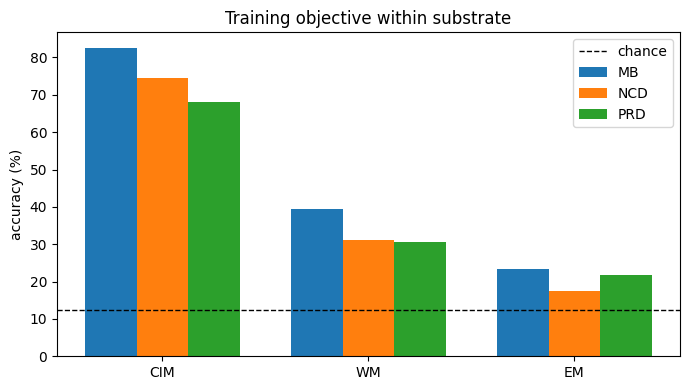

In [13]:
tables()
plot_objectives()

## 9. Results and how to read them

**Run configuration.** Colab T4, procedural 3×3 testbed, 2,000 training
problems, 500 test, 10 epochs, `img_size=64`, **1 seed**, `stages=3` for all
substrates (relational depth matched). 9 of 19 cells complete. Chance = 12.5%.

### Table 1 — substrate × objective (3×3), accuracy %

| substrate | MB | NCD | PRD | MB advantage |
|---|---|---|---|---|
| CIM | **82.6** | 74.4 | 68.2 | +8.2 over NCD |
| WM  | **39.4** | 31.2 | 30.6 | +8.2 over NCD |
| EM  | **23.4** | 17.4 | 21.8 | +1.6 over PRD |

Tables 2–4 are unrun (block A only).

### 1. Yang et al.'s claim replicates, in its strong form

MB is the best objective in **all three substrates**. Reading within a row
holds the substrate fixed, so this comparison is uncontaminated by
architecture. And because the ordering survives replacing the CIM with two
completely different context substrates, it supports the authors' framing that
MB is a **training paradigm rather than a property of their architecture** —
which is precisely what their table S4 was arguing and what the paper's
discussion claims ("MB in our model is a training paradigm rather than a
computational module").

### 2. But the effect size does not replicate

This is the most important qualification. Yang et al.'s table S4 reports
VPM+CIM+NCD at **22.5** and VPM+CIM+PRD at **13.0** against **88.3** for MB —
a near-total collapse. Here NCD reaches **74.4**, only 8.2 points behind MB.
The *direction* replicates; the *magnitude* does not, by a wide margin.

Candidate explanations, none yet distinguished:

* My NCD and PRD are **reimplementations from the paper's prose description**,
  not ports. If they are gentler than the originals, the gap shrinks.
* The procedural testbed is likely **easier than RAVEN** — three attributes,
  one object per cell, four rule families. Weaker objectives may still suffice
  where they would fail on RAVEN's seven spatial configurations.
* **One seed.** No error bars.

Anyone citing this should say "MB wins consistently but modestly on a
simplified testbed", not "table S4 reproduced".

### 3. CIM+MB lands near the published number — treat as coincidence

82.6 here vs 83.8 reported on RAVEN. Tempting, but the notebook trains on
2,000 problems for 10 epochs against their 70,000 for 100, so matching their
accuracy signals that **this testbed is easier**, not that the result was
reproduced. It is a sanity check that the vendored pipeline works, nothing
more. (The architecture itself *is* verified: 1,266,497 parameters against the
paper's reported 1.27 M.)

### 4. The NCD-vs-PRD ordering is unstable — treat as noise

An earlier CPU pilot gave MB > **PRD** > NCD; this run gives MB > **NCD** >
PRD for CIM and WM. The two baselines swap places across runs. Only the
**MB-over-both** gap is consistent. Do not report an NCD/PRD difference from
single-seed data.

### 5. Whittington et al.'s claim is still untested

Nothing here bears on it. The EM/WM duality is a claim about **memory load**,
and the load manipulation (Tables 2–3) has not been run. The cross-substrate
ordering in Table 1 shows only that convolution across the image axis is a
better inductive bias for *induction* than either memory substrate — which is
unsurprising, since both were built for *recall*.

Note also that the size sweep as designed is confounded: in the pilot,
accuracy went **up** from 3×3 to 4×4, because wider matrices add constraining
evidence and an extra test subproblem faster than they add memory load. **The
`d_h` sweep in block C is the only clean capacity test in this notebook.**

### Honest limitations

1. **The WM and EM heads are extensions, not the published models.** The
   published EM/WM do *recall*; RPM needs *inference*. They are used here as
   context-holding substrates with a shared relational readout. The fair
   reading is "does it matter whether context is held in a fixed activation
   budget or a growing store, all else equal" — **not** "Whittington's model
   scores X on RAVEN."
2. **NCD and PRD are reimplementations** from prose. See point 2 above.
3. **Generated tasks, not the published datasets.** No PGM-style XOR/OR/AND
   over object sets; the OOD test is weaker evidence than PGM's held-out
   splits.
4. **One seed, 500 test problems.** The 95% binomial interval at 39% accuracy
   on n=500 is roughly ±4.3 points, so treat any gap under ~9 points as
   provisional — including the +8.2 MB advantages in Table 1.
5. **Parameter counts are not matched** across substrates (1.27 / 1.63 /
   2.29 M). They run against the winner, which helps, but they are not
   controlled.

## 10. Next steps, in priority order

1. **Run blocks B–D** (`benchmark_cells()[9:]`). Until block C's `d_h` sweep
   exists, half the notebook's stated purpose is unaddressed.
2. **Add seeds** (`seeds=(0,1,2)`). Every conclusion above rests on n=1.
3. **Replace the width sweep with a load manipulation that does not add
   evidence** — hold 3×3 and pad with task-irrelevant distractor cells, so
   item count rises while the rule evidence stays constant.
4. **Swap in the real datasets.** Use the authors' loaders in
   `SSLvMBcode/RPMcode/data/{raven,pgm}.py` against I-RAVEN / RAVEN-FAIR /
   PGM. Their recipe:

   ```
   --arch sslvmb --num-extra-stages 3 --unsupervised-training \
   --block-drop 0.1 --classifier-drop 0.5 \
   --batch-size 128 --lr 0.001 --wd 1e-5 --image-size 96 --epochs 100
   ```

   with 5 seeds (`12341…12345`). This is also the way to find out whether the
   table S4 magnitude gap in point 2 is a testbed artefact.
5. **Substitute the original NCD and PRD implementations** so the baselines
   carry real weight.

### The complementary experiment worth doing

Run the arrow the other way. Take **Whittington et al.'s** sequence-recall
tasks from the `em-wm-slots` repo (`parameters.py` line 78 switches
`model_type` between `"WM"` and `"EM"`; `environments.py` holds `Loop`,
`LoopDelay`, `NBack`, `Panichello2021`, `Xie2022`) and ask whether MB-style
training on *reduced* sequences improves EM/WM generalisation to longer ones.

That tests Yang et al.'s paradigm on Whittington et al.'s home ground, where
EM and WM are the appropriate models rather than transplants — and it is the
version of "benchmark these two papers against each other" that neither
requires extending a recall model into an induction model nor handicaps it.